In [3]:
library(infer)
library(tidyverse)
library(broom)
library(dplyr)

Warning message:
"package 'infer' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [6]:
sleep <- read_csv("cmu-sleep.csv") |>
  mutate(demo_gender = recode(demo_gender, "1" = "female", "0" = "male"),
         demo_race = recode(demo_race, "1" = "non-under", "0" = "under"),
         demo_firstgen = recode(demo_firstgen, "1" = "first", "0" = "non-first"),
         study = as.factor(study))

Rows: 634 Columns: 15
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): cohort
dbl (14): subject_id, study, demo_race, demo_gender, demo_firstgen, bedtime_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
"There was 1 warning in `mutate()`.
ℹ In argument: `demo_firstgen = recode(demo_firstgen, `1` = "first", `0` = "non-first")`.
Caused by warning:
! Unreplaced values treated as NA as `.x` is not compatible.
Please specify replacements exhaustively or supply `.default`."


study period (explanation of column 2):
1. CMU Spring 2018
2. UW Spring 2018
3. UW Spring 2019
4. ND Spring 2016
5. CMU Spring 2017

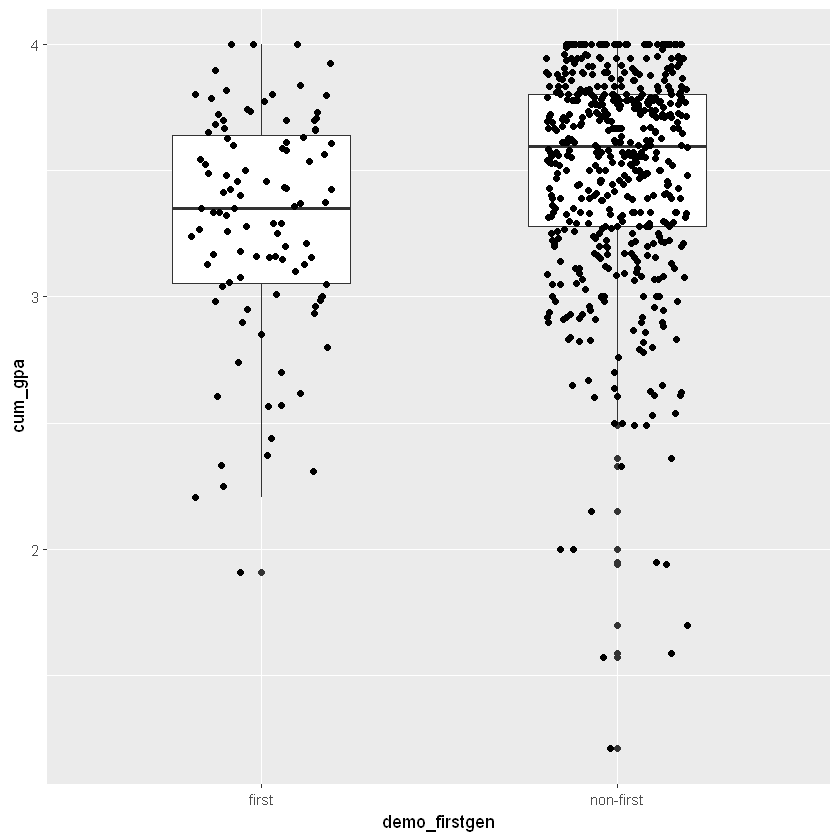

In [11]:
firstgen_gpa <- sleep %>% filter(!is.na(demo_firstgen))
gender_gpa <- sleep %>% filter(!is.na(demo_gender))
race_gpa <- sleep %>% filter(!is.na(demo_race))
firstgen_gpa %>% ggplot(aes(x = demo_firstgen, y = cum_gpa)) +
  geom_boxplot(width = 0.5) +
  geom_jitter(width = 0.2)

We first looked into the impact of family education background, race and gender on cumulative gpa.

Warning message:
"Please be cautious in reporting a p-value of 0. This result is an approximation based on the number of `reps` chosen in
the `generate()` step.
ℹ See `get_p_value()` (`?infer::get_p_value()`) for more information."


p_value
<dbl>
0


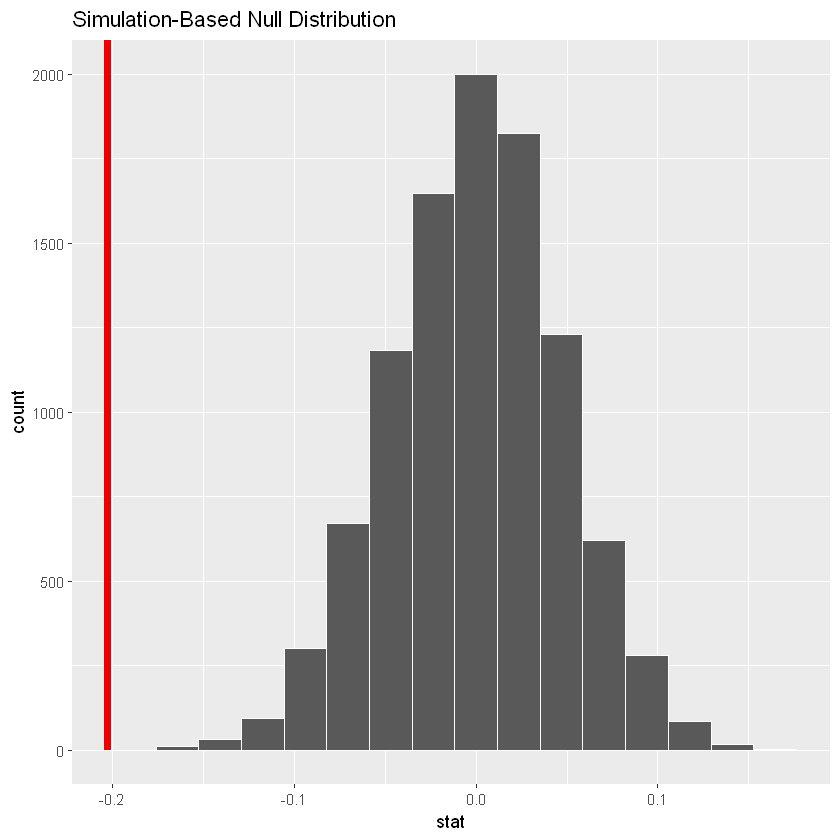

In [12]:
alpha <- 0.01
obsdiff_firstgen <- firstgen_gpa %>% specify(formula = cum_gpa~demo_firstgen) %>% 
  calculate(stat = "diff in means", order = c("first", "non-first"))
#construct a null distribution of 10000 samples of mean gpa gap between the groups (below)
null_dist_firstgen_gpa <- firstgen_gpa %>% 
  specify(formula = cum_gpa~demo_firstgen) %>% 
  hypothesize(null = "independence") %>% 
  generate(reps = 10000, type = "permute") %>%
  calculate(stat = "diff in means", order = c("first", "non-first"))
null_dist_firstgen_gpa %>% visualise() + shade_p_value(obsdiff_firstgen, direction = "less")
p_val <- null_dist_firstgen_gpa %>% get_p_value(obs_stat = obsdiff_firstgen, direction = "less")
p_val

Since the p-value is treated as 0 when alpha is 0.01, it can be concluded that the first-generation university students normally achieve a lower overall gpa than those whose parents have a higher education background, with a significance level of 1%.

In [13]:
tidy(t.test(x=(firstgen_gpa %>% filter(demo_gender == "female"))$cum_gpa,
            y=(firstgen_gpa %>% filter(demo_gender == "male"))$cum_gpa,
            alternative = "two.sided"))

estimate,estimate1,estimate2,statistic,p.value,parameter,conf.low,conf.high,method,alternative
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
0.01583631,3.472391,3.456555,0.4328826,0.6652851,504.5488,-0.05603822,0.08771085,Welch Two Sample t-test,two.sided


Since the p-value is 0.665 when the significance level alpha is 0.95, it can be concluded that the gender difference has no great influence on cumulative GPA, under a 95% confidence interval.

In [14]:
tidy(t.test(x=(race_gpa %>% filter(demo_race == "non-under"))$cum_gpa,
            y=(race_gpa %>% filter(demo_race == "under"))$cum_gpa,
            alternative = "greater"))

estimate,estimate1,estimate2,statistic,p.value,parameter,conf.low,conf.high,method,alternative
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
0.2063677,3.504074,3.297707,4.033171,4.333733e-05,152.6739,0.1216907,Inf,Welch Two Sample t-test,greater


Since the p-value is 0.00004 when the significance level alpha is 0.95, the students from the underrepresented race achieve lower cumulative GPA than those from the non-underrepresented race.

In [16]:
alpha <- 0.05
sd_diff <- sleep %>% select(study, TotalSleepTime) %>% group_by(study) %>% 
  summarize(sd = sd(TotalSleepTime))
aov_result <- tidy(aov(TotalSleepTime ~ study, data = sleep))
aov_judge<- aov_result$statistic[1] > qf(1-alpha, 4, nrow(sleep) - 5)
aov_result
aov_judge

term,df,sumsq,meansq,statistic,p.value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
study,4,108939.8,27234.955,11.20937,8.629889e-09
Residuals,629,1528255.5,2429.659,NA,NA


[1] TRUE

Since the F-ratio exceeds the F-critical value at alpha = 0.05, it can be claimed that at least one category's total sleep time differs from the others. 

To probe into which categories have apparently different total sleep time from the others, the posthoc analysis is applied below using the Bonferroni method.

In [17]:
pw_result <- pairwise.t.test(sleep$TotalSleepTime, sleep$study, 
                             p.adjust.method = "bonferroni") $ p.value
sleep %>% group_by(study) %>% 
  summarize(mean_sleep = mean(TotalSleepTime),
            sd_sleep = sd(TotalSleepTime),
            n = n())

study,mean_sleep,sd_sleep,n
<fct>,<dbl>,<dbl>,<int>
1,378.9140,53.91119,77
2,412.9890,50.80455,140
3,410.0179,46.90596,139
4,385.1481,49.86999,147
5,391.5973,46.56402,131


We concluded that students in categories 2 and 3 (uw students) have significantly longer sleep time on average compared with 
those from the other categories, with a significance level of 0.05.

Since parents' education backgrounds, race and course loads all have impacts on GPA, we control the first two variables and extract the 80% quantile of term units number to see whether there is a correlation between total sleep time and term GPA. Since the non-first group accounts for the majority of the students, we only focus on the non-first group.

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


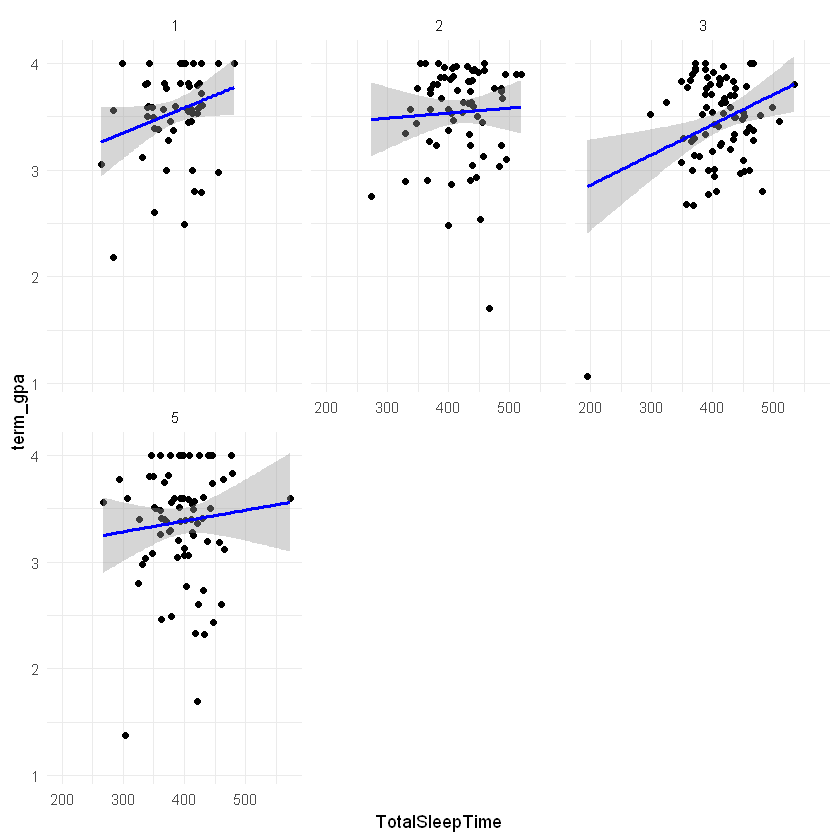

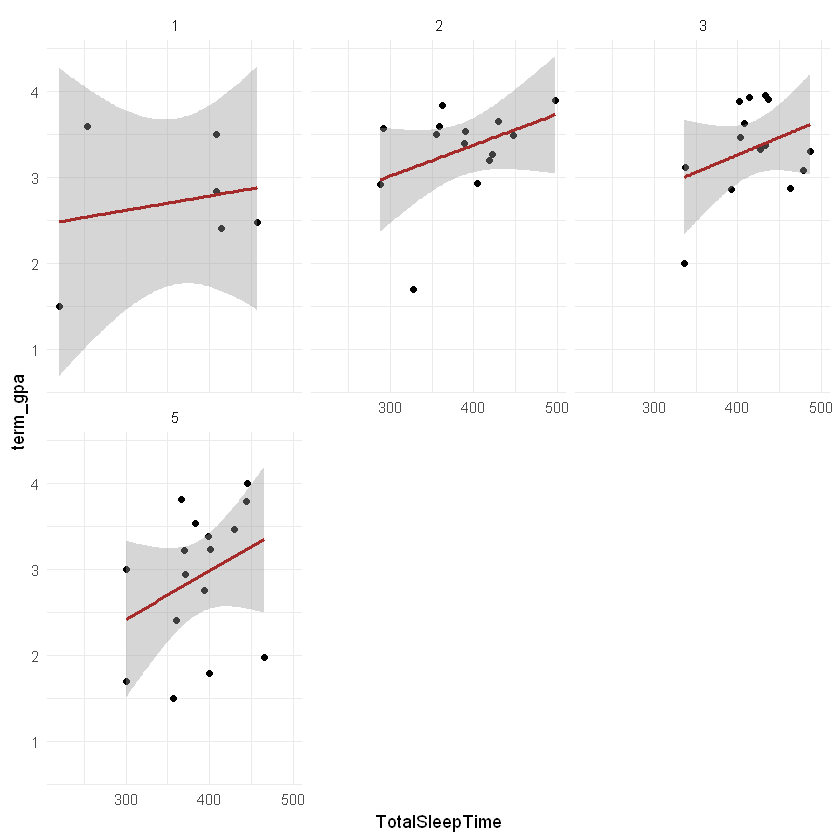

In [18]:
maj <- sleep %>% filter(!is.na(term_units)) %>%
  summarize(lower = quantile(term_units, 0.1), 
            upper = quantile(term_units, 0.9))
sleep %>% filter(demo_firstgen == "non-first" & demo_race == "non-under" &
           between(term_units, maj$lower, maj$upper)) %>% 
  group_by(study) %>% ggplot(aes(x = TotalSleepTime, y = term_gpa)) +
  geom_point() + geom_smooth(method = "lm", se = TRUE, color = "blue") +
  facet_wrap(~ study, ncol = 3) + theme_minimal()
sleep %>% filter(demo_firstgen == "non-first" & demo_race == "under" &
                   between(term_units, maj$lower, maj$upper)) %>% 
  group_by(study) %>% ggplot(aes(x = TotalSleepTime, y = term_gpa)) +
  geom_point() + geom_smooth(method = "lm", se = TRUE, color = "brown") +
  facet_wrap(~ study, ncol = 3) + theme_minimal()

As we see from the five categories, all of them indicate a positive correlation between total sleep time and students' GPA, with the exclusion of disturbing factors. In this sense, are UW students more likely to ace their GPAs?

In [19]:
alpha = 0.05
sd_diff_uni <- sleep %>% select(study, term_gpa) %>% group_by(study) %>% 
  summarize(sd = sd(term_gpa))
aov_gpa_uni <- aov(term_gpa~study, data = sleep) %>% tidy()
pw_result_uni <- pairwise.t.test(sleep$term_gpa, sleep$study, 
                             p.adjust.method = "bonferroni") $ p.value
sleep %>% group_by(study) %>% 
  summarize(mean_gpa = mean(term_gpa),
            sd_gpa = sd(term_gpa))

study,mean_gpa,sd_gpa
<fct>,<dbl>,<dbl>
1,3.479740,0.5105286
2,3.490297,0.4488787
3,3.325755,0.5674900
4,3.664584,0.2660834
5,3.278550,0.5743895


Notre Dame University students have significantly higher GPAs than UW students, which might indicate some other factors (learning difficulty, prof resources) that might affect GPA. But sleep time does improve students' academic performance in some way.

Lastly, we can predict the GPA of 2018 CMU students during spring with a total sleep time of 360 h/month.

In [21]:
filtered <- sleep %>% filter(!is.na(term_gpa) & !is.na(TotalSleepTime))
model <- lm(term_gpa~study+TotalSleepTime, data = filtered)
new <- data.frame(study = factor("1", levels = levels(filtered$study)),
                  TotalSleepTime = 360)
predicted <- predict(model, new, interval = "confidence")
predicted

,fit,lwr,upr
1,3.434224,3.328902,3.539546


It is concluded that the CMU freshmen with a total sleep time of 360 hours during a month in Spring 2018 are expected to achieve 3.43 for the term on average, with a 95% confidence interval ranging from 3.33 to 3.54.